# Cox relative-hazard explanations: measured approximation and exactness

This notebook tests whether a small quadrature rule can explain a model with tens or hundreds of thousands of features quickly, and measures what the sufficient exact rule actually costs. We fit a ridge-regularized Cox model to **GSE24080 myeloma**, run approximate and exact QuadraSHAP on the same model and background, then run approximations on **TCGA LGG methylation**.

The fitted models are research baselines with a fixed penalty, not a tuned clinical prediction study. The survival labels are overall-survival time and death indicators. Features and preprocessing come from the [dataset guide](../data/experiments/README.md).

**Scope of timing:** loading, preprocessing, model fitting, prediction scoring, quadrature-rule generation, integration, and complete attribution calls are timed separately with `perf_counter`. Approximate timings use three cached-rule repetitions per patient; exact timing is one complete call for the first validation patient. Package installation and notebook authoring are not included.

In [1]:
from pathlib import Path
import sys, os, time, json
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
assert (ROOT / "src/quadrashap").exists()
sys.path[:0] = [str(ROOT / "src"), str(ROOT)]
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/quadrashap-cox-matplotlib")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits, threadpool_info
from benchmarks.cox_experiment import (environment, write_json, fit_dataset,
    benchmark_approximate, benchmark_exact, comparison_table)
NOTEBOOK_START = time.perf_counter()
OUTPUT = ROOT / "benchmarks/results/cox_survival"
OUTPUT.mkdir(parents=True, exist_ok=True)
THREAD_LIMIT = threadpool_limits(limits=4)  # Applies to supported BLAS libraries.
ENV = environment()
ENV["threadpool_info"] = threadpool_info()
ENV["requested_blas_threads"] = 4
write_json(OUTPUT / "environment.json", ENV)
display(pd.Series(ENV["packages"], name="version"))
print(ENV["platform"])
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

Matplotlib is building the font cache; this may take a moment.


numpy               2.5.2
scipy              1.18.1
pandas              3.0.5
scikit-learn        1.9.0
scikit-survival    0.28.0
matplotlib         3.11.2
Name: version, dtype: str

macOS-26.6.2-arm64-arm-64bit-Mach-O


## Why the Cox model is a product game

A positive contribution should mean an increase in the model's relative hazard above its average value on the chosen background. This is the multiplicative output identified in Table 1 and Section 4 of the repository paper:

$$f(x)=\frac{h(t\mid x)}{h_0(t)}=\exp(\beta^\top x)=\prod_j\exp(\beta_jx_j).$$

Here $h_0(t)$ is the baseline hazard, shared by observations, and $\beta$ is fitted on standardized features. We explain $f$, not log relative hazard or survival probability. The baseline *explanation value*, $\bar f_B$, is an average model output; it is different from $h_0(t)$.

A coalition is a subset $S$ of features kept at the explained patient's values. All other values come from a whole background patient $z_b$:

$$v(S)=\frac1B\sum_b \exp\!\left(\sum_{j\in S}\beta_jx_j+\sum_{j\notin S}\beta_jz_{bj}\right).$$

The background is four reproducibly selected training patients. This is a deliberately small empirical game for the first timing experiment. Both exact and approximate methods use **the same four rows**. Increasing the background changes the game and increases work; quadrature accuracy here does not measure error from using a small background.

For $\delta_{bj}=\beta_j(x_j-z_{bj})$ and $K_{bj}=\exp(\delta_{bj})-1$, QuadraSHAP evaluates

$$\phi_i=\frac1B\sum_b e^{\beta^\top z_b}K_{bi}\int_0^1\prod_{j\ne i}(1+tK_{bj})\,dt.$$

The integrand has degree at most $d_{\rm active}-1$, so $m_q\ge\lceil d_{\rm active}/2\rceil$ is sufficient for algebraic exactness. Floating-point arithmetic still introduces roundoff. Small $m_q$ is a quadrature approximation even when its observed error is near machine precision. Summing the contributions should recover $f(x)-\bar f_B$, but this sum alone does not validate every feature contribution.

## Fit a dense ridge Cox model without a feature-by-feature Hessian

To keep the large feature dimension meaningful, ridge regularization shrinks coefficients without intentionally making most of them zero. A direct second-order solver would need a $d\times d$ matrix. We instead fit in the space spanned by the training rows, which has dimension at most the number of patients, then map the coefficients back to **all original retained features**.

Concretely, if the standardized training matrix has thin decomposition $X=U\Sigma V^\top$, fitting on $U\Sigma$ and setting $\beta=V\theta$ preserves predictions and the ridge norm $\|\beta\|^2=\|\theta\|^2$. We retain all numerically non-null training directions. This is a coordinate change, not choosing a small feature subset; attribution still treats individual original features as players. A unit test compares coefficients and held-out predictions with a direct ridge Cox fit, including tied times and dependent features.

We use scikit-survival's Cox solver with Breslow handling of tied event times. Its objective is negative partial log likelihood plus $\alpha\|\beta\|^2/2$, divided by the training sample count. The fixed setting is $\alpha=0.01d$; no validation-set tuning is performed. Medians, means, and scales are fitted on training patients only. Features missing or constant throughout training are removed.

In [2]:
myeloma = fit_dataset("gse24080", OUTPUT)
display(pd.Series(myeloma["summary"], name="myeloma"))

gse24080: 339 training patients, 54,675 features; fit 0.528s; validation C-index 0.657


dataset                                                       gse24080
n                                                                  553
n_train                                                            339
n_test                                                             214
input_features                                                   54675
used_features                                                    54675
nonzero_coefficients                                             54675
training_rank                                                      338
rank_tolerance                                                0.000002
train_events                                                       125
test_events                                                         43
split                               Provided training/validation split
seed                                                                42
ridge_alpha                                                     546.75
ridge_

## Approximate attribution: increasing the node budget

We explain the first three validation patients, selected without inspecting their outcomes or predictions. The backend evaluates the paper's shared product in logarithms and processes small blocks of quadrature nodes. This bounds temporary memory while retaining the same integral. The first call and cached-rule repetitions are stored separately. All feature calculations use float64.

In [3]:
myeloma_timings = benchmark_approximate(myeloma)
display(myeloma_timings[myeloma_timings.phase.eq("cached_rule")].groupby("m_q")[
    ["total_seconds", "integration_seconds"]].median())

gse24080: approximate m_q=1 completed for 3 patients


gse24080: approximate m_q=2 completed for 3 patients


gse24080: approximate m_q=4 completed for 3 patients


gse24080: approximate m_q=8 completed for 3 patients


gse24080: approximate m_q=16 completed for 3 patients


gse24080: approximate m_q=32 completed for 3 patients


gse24080: approximate m_q=64 completed for 3 patients


gse24080: approximate m_q=128 completed for 3 patients


,total_seconds,integration_seconds
m_q,,
1,0.004980,0.003936
2,0.006061,0.005088
4,0.009273,0.007963
8,0.014299,0.013261
16,0.026338,0.025318
32,0.048657,0.047515
64,0.089908,0.088951
128,0.181374,0.180276


## Run the full exact rule

This uses every retained feature, the same fitted coefficients, the same four background patients, and the first validation patient above. The node count is the sufficient exactness threshold, not an extrapolated runtime. Rule generation is included in the cold total and reported separately. The integration safety limit is ten minutes; a timeout would be recorded explicitly and would not be presented as an exact result.

In [4]:
exact_started = time.perf_counter()
try:
    exact_timing = benchmark_exact(myeloma, timeout_seconds=600)
except TimeoutError as exc:
    exact_timing = {"status": "timeout", "elapsed_seconds": time.perf_counter() - exact_started,
                    "message": str(exc)}
    write_json(myeloma["output"] / "exact_timeout.json", exact_timing)
display(pd.Series(exact_timing))
myeloma_comparison = comparison_table(myeloma)
display(myeloma_comparison.query("patient == 0")[["m_q", "reference", "median_seconds",
    "relative_l2_error", "max_absolute_error", "top20_overlap", "relative_efficiency_residual"]])

Starting full exact rule: 27,338 nodes, 54,675 features, 4 background patients


Exact completed: 48.634s total; 10.147s rule generation; 38.485s integration


base_value                                                    53.328749
prediction                                                      7.49514
m_q                                                               27338
exact_nodes                                                       27338
active_features                                                   54675
rule_seconds                                                   10.14691
integration_seconds                                           38.485284
total_seconds                                                 48.633705
patient                                                               0
repeats                                                               1
reference              Algebraically exact Gauss-Legendre rule, float64
dtype: object

,m_q,reference,median_seconds,relative_l2_error,max_absolute_error,top20_overlap,relative_efficiency_residual
0,1,exact,0.004859,3.112051e-01,1.645061e-01,0.95,2.445402e-01
3,2,exact,0.006061,1.466273e-02,7.706826e-03,1.00,7.016555e-03
6,4,exact,0.008813,2.393016e-06,1.172187e-06,1.00,2.599788e-06
9,8,exact,0.014172,8.657404e-13,4.559686e-13,1.00,3.664051e-16
12,16,exact,0.027295,8.649049e-13,4.556355e-13,1.00,4.330242e-16
15,32,exact,0.048340,8.640558e-13,4.549694e-13,1.00,1.099215e-15
18,64,exact,0.092433,8.618656e-13,4.544143e-13,1.00,2.698074e-15
21,128,exact,0.178160,8.685081e-13,4.575229e-13,1.00,2.098502e-15


## Larger-dimension experiment: glioma methylation

This cohort starts with 396,065 measured sites and 511 patients. It uses a reproducible 75/25 split stratified by the event indicator. The fitted model and attribution workflow are identical, with the same fixed penalty rule. We run the approximation sweep here and report its agreement with 128 nodes. **The 128-node result is a convergence reference, not an exact ground truth.** The full sufficient exact rule is executed above on the myeloma cohort; it is not executed on this larger cohort in this notebook.

In [5]:
glioma = fit_dataset("tcga_lgg_methylation", OUTPUT)
display(pd.Series(glioma["summary"], name="glioma"))
glioma_timings = benchmark_approximate(glioma)
glioma_comparison = comparison_table(glioma)
display(glioma_comparison.query("patient == 0")[["m_q", "reference", "median_seconds",
    "relative_l2_error", "max_absolute_error", "top20_overlap", "relative_efficiency_residual"]])

tcga_lgg_methylation: 383 training patients, 396,065 features; fit 1.174s; validation C-index 0.854


dataset                                           tcga_lgg_methylation
n                                                                  511
n_train                                                            383
n_test                                                             128
input_features                                                  396065
used_features                                                   396065
nonzero_coefficients                                            396065
training_rank                                                      382
rank_tolerance                                                0.000021
train_events                                                        94
test_events                                                         31
split                         75/25 split stratified by event, seed 42
seed                                                                42
ridge_alpha                                                    3960.65
ridge_

tcga_lgg_methylation: approximate m_q=1 completed for 3 patients


tcga_lgg_methylation: approximate m_q=2 completed for 3 patients


tcga_lgg_methylation: approximate m_q=4 completed for 3 patients


...

tcga_lgg_methylation: approximate m_q=16 completed for 3 patients


tcga_lgg_methylation: approximate m_q=32 completed for 3 patients


tcga_lgg_methylation: approximate m_q=64 completed for 3 patients


tcga_lgg_methylation: approximate m_q=128 completed for 3 patients


,m_q,reference,median_seconds,relative_l2_error,max_absolute_error,top20_overlap,relative_efficiency_residual
0,1,128-node approximation,0.046170,6.879501e-01,2.202536e-02,1.0,6.912766e-01
3,2,128-node approximation,0.056083,1.233312e-01,3.975852e-03,1.0,1.257056e-01
6,4,128-node approximation,0.075617,3.597599e-04,1.166322e-05,1.0,3.742297e-04
9,8,128-node approximation,0.121946,2.415616e-11,7.717924e-13,1.0,2.519206e-11
12,16,128-node approximation,0.196530,9.789964e-15,3.122502e-16,1.0,2.943118e-16
15,32,128-node approximation,0.372133,1.254682e-14,4.024558e-16,1.0,3.090274e-15
18,64,128-node approximation,0.703420,1.888528e-14,6.106227e-16,1.0,9.565134e-15
21,128,128-node approximation,1.375421,0.000000e+00,0.000000e+00,1.0,9.565134e-15


## Measured cost and observed error

Relative attribution error is $\|\hat\phi-\phi_{\mathrm{ref}}\|_2/\|\phi_{\mathrm{ref}}\|_2$. For the first myeloma patient, the reference is the full exact rule; for glioma it is the 128-node approximation. The figure shows the first patient in each cohort. Timings are local CPU measurements and depend on hardware, background size, and implementation.

For display on the logarithmic axis, errors below `1e-16` are shown at `1e-16`. The glioma point at 128 nodes is a comparison of the reference with itself, so its true reported difference is zero; this point is not independent accuracy evidence. The myeloma plateau around `1e-12` includes roundoff in the high-order exact-rule reference.

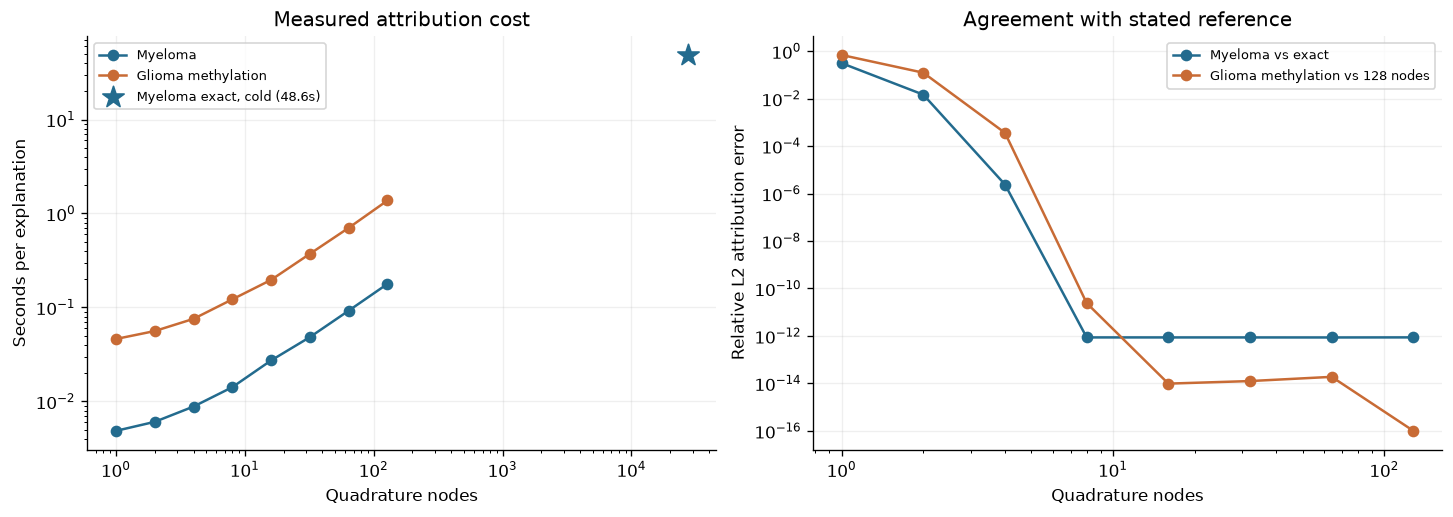

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for frame, label, color in [(myeloma_comparison, "Myeloma", "#236B8E"),
                            (glioma_comparison, "Glioma methylation", "#C86B35")]:
    first = frame.query("patient == 0")
    axes[0].loglog(first.m_q, first.median_seconds, "o-", label=label, color=color)
    axes[1].loglog(first.m_q, np.maximum(first.relative_l2_error, 1e-16), "o-",
                  label=label + (" vs exact" if label == "Myeloma" and "exact" in myeloma else " vs 128 nodes"), color=color)
if "exact" in myeloma:
    exact = myeloma["exact"]
    axes[0].scatter([exact.m_q], [exact.total_seconds], marker="*", s=180, color="#236B8E",
                    label=f"Myeloma exact, cold ({exact.total_seconds:.1f}s)", zorder=5)
axes[0].set(xlabel="Quadrature nodes", ylabel="Seconds per explanation", title="Measured attribution cost")
axes[1].set(xlabel="Quadrature nodes", ylabel="Relative L2 attribution error", title="Agreement with stated reference")
for ax in axes:
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.savefig(OUTPUT / "runtime_and_accuracy.png", dpi=200)
fig.savefig(OUTPUT / "runtime_and_accuracy.svg")
plt.show()

## Which measured inputs drive one relative-hazard prediction?

Positive values increase relative hazard above its background average; negative values decrease it. The feature IDs below are expression probe IDs, not verified gene annotations. The plot shows the largest 15 individual contributions; all omitted contributions remain in the saved arrays and efficiency check. These are model explanations, not causal effects.

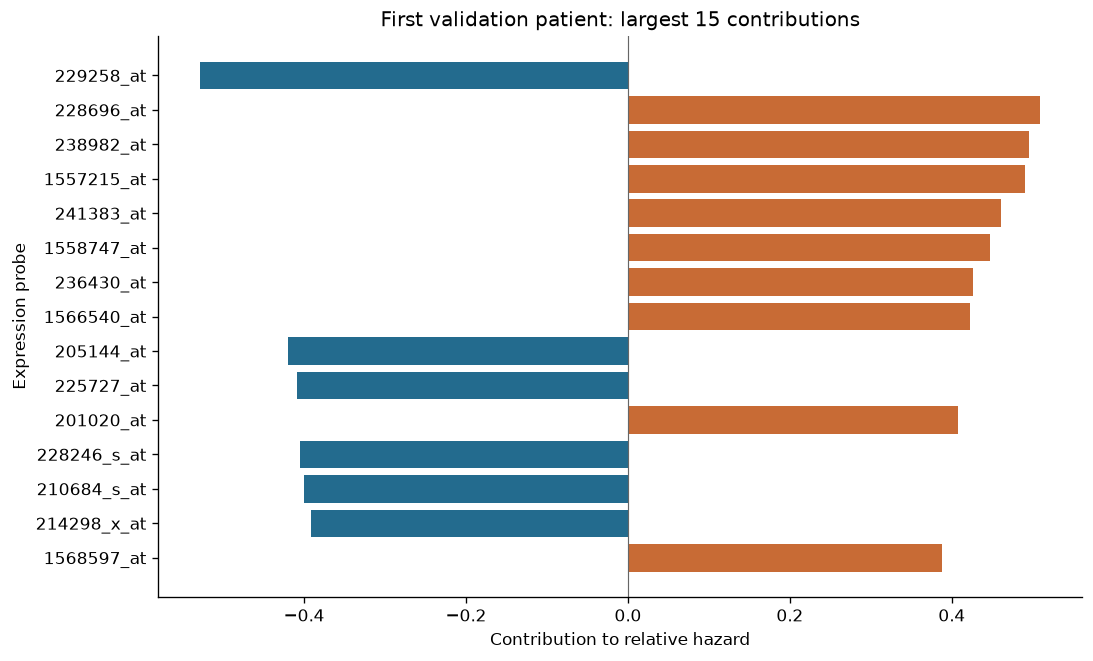

background_mean_relative_hazard    5.332875e+01
sum_of_all_contributions          -4.583361e+01
patient_relative_hazard            7.495140e+00
efficiency_residual                3.483969e-11
dtype: float64

In [7]:
reference = myeloma.get("exact", myeloma["approximations"][(0, 128)])
order = np.argsort(np.abs(reference.values))[-15:]
fig, ax = plt.subplots(figsize=(9, 5.4), constrained_layout=True)
vals = reference.values[order]
ax.barh(myeloma["features"][order], vals, color=np.where(vals >= 0, "#C86B35", "#236B8E"))
ax.axvline(0, color="0.4", lw=.7)
ax.set(xlabel="Contribution to relative hazard", ylabel="Expression probe",
       title="First validation patient: largest 15 contributions")
fig.savefig(OUTPUT / "myeloma_feature_contributions.png", dpi=200)
fig.savefig(OUTPUT / "myeloma_feature_contributions.svg")
plt.show()
display(pd.Series({"background_mean_relative_hazard": reference.base_value,
                  "sum_of_all_contributions": reference.values.sum(),
                  "patient_relative_hazard": reference.prediction,
                  "efficiency_residual": reference.efficiency_residual}))

## Interpretation and saved results

The central comparison is empirical: how quickly do a few nodes approach the exact myeloma result? The polynomial-degree bound is sufficient in the worst case, so an observed smooth integrand can need far fewer nodes for numerical accuracy. Agreement with 128 nodes and a small efficiency residual on glioma are useful diagnostics, but do not certify every attribution's error.

The notebook does not claim an experimentally validated formal bound, tuned predictive performance, population-level generalization, or accuracy for an entire training-set background. Model discrimination is reported using the concordance index: among comparable patient pairs, how often the patient with earlier observed death receives higher predicted risk. An index around 0.5 corresponds to chance ranking. The two models have only one train/test split and a fixed penalty.

`benchmarks/results/cox_survival/` contains fit summaries, model/preprocessing arrays, patient roles, validation predictions, raw timing repetitions, full attribution arrays, comparison tables, plots, and software versions. A rerun replaces this experiment's saved results. `approximation_timings.csv` separates first calls from cached-rule repetitions; `exact_timing.json` records the single exact call.

References: the repository paper's Table 1 and Section 4; [scikit-survival Cox model documentation](https://scikit-survival.readthedocs.io/en/stable/api/generated/sksurv.linear_model.CoxPHSurvivalAnalysis.html); [Gauss–Legendre rule documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.roots_legendre.html); source datasets linked in the [dataset guide](../data/experiments/README.md).

In this run, training concordance was nearly one in both cohorts, while held-out concordance was about 0.657 (myeloma) and 0.854 (glioma). That gap motivates tuning and repeated validation before making predictive claims. The timing experiment retains the fixed baseline models. Large model and attribution arrays are saved locally but ignored by Git.

In [8]:
workflow_seconds = time.perf_counter() - NOTEBOOK_START
summary_rows = []
for experiment, frame in [(myeloma, myeloma_comparison), (glioma, glioma_comparison)]:
    s = experiment["summary"]
    row = {"dataset": s["dataset"], "n_train": s["n_train"], "d_active": s["nonzero_coefficients"],
           "preprocessing_seconds": s["preprocessing_seconds"], "fit_seconds": s["fit_seconds"],
           "validation_c_index": s["test_c_index"], "sufficient_exact_nodes": s["exact_nodes"]}
    first = frame.query("patient == 0")
    for m_q in [8, 16, 32, 128]:
        q = first[first.m_q == m_q].iloc[0]
        row[f"mq_{m_q}_seconds"] = float(q.median_seconds)
        row[f"mq_{m_q}_relative_l2_error"] = float(q.relative_l2_error)
    row["error_reference"] = first.reference.iloc[0]
    row["exact_total_seconds"] = experiment["exact"].total_seconds if "exact" in experiment else None
    summary_rows.append(row)
summary_table = pd.DataFrame(summary_rows)
summary_table.to_csv(OUTPUT / "summary.csv", index=False)
write_json(OUTPUT / "run_summary.json", {"workflow_seconds": workflow_seconds,
           "datasets": summary_rows, "approximate_repeats": 3, "exact_repeats": 1,
           "background_size": 4, "explained_patients_per_cohort": 3})
display(summary_table)
print(f"Measured notebook workflow: {workflow_seconds:.2f} seconds (excluding imports, installation, and authoring)")

,dataset,n_train,d_active,preprocessing_seconds,fit_seconds,validation_c_index,sufficient_exact_nodes,mq_8_seconds,mq_8_relative_l2_error,mq_16_seconds,mq_16_relative_l2_error,mq_32_seconds,mq_32_relative_l2_error,mq_128_seconds,mq_128_relative_l2_error,error_reference,exact_total_seconds
0,gse24080,339,54675,1.207905,0.528358,0.657053,27338,0.014172,8.657404e-13,0.027295,8.649049e-13,0.048340,8.640558e-13,0.178160,8.685081e-13,exact,48.633705
1,tcga_lgg_methylation,383,396065,10.733213,1.173621,0.853791,198033,0.121946,2.415616e-11,0.196530,9.789964e-15,0.372133,1.254682e-14,1.375421,0.000000e+00,128-node approximation,NaN


Measured notebook workflow: 109.61 seconds (excluding imports, installation, and authoring)
